In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv('beverage_cleaned.csv')

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Data loaded successfully!
Shape: (29998, 16)


,id,sale_year,sale_month,supplier,item_code,item_desc,item_type,retail_sales,retail_transfers,warehouse_sales,month_name,total_units,dominant_channel,item_type_clean,is_return,is_dead_stock
0,1,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,January,2.00,Warehouse,WINE,0,1
1,2,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,January,5.00,Warehouse,WINE,0,1
2,3,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,January,1.00,Warehouse,BEER,0,1
3,4,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,January,1.00,Warehouse,WINE,0,1
4,5,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,January,0.82,Retail,WINE,0,0


In [3]:
features_df = df[[
    'sale_month',
    'supplier',
    'item_code',
    'item_type_clean',
    'retail_sales',
    'warehouse_sales',
    'retail_transfers',
    'is_dead_stock',
    'is_return',
    'dominant_channel'
]].copy()

# Encode categorical columns using LabelEncoder
le_supplier = LabelEncoder()
le_item_code = LabelEncoder()
le_item_type = LabelEncoder()
le_dominant_channel = LabelEncoder()

features_df['supplier_encoded'] = le_supplier.fit_transform(features_df['supplier'])
features_df['item_code_encoded'] = le_item_code.fit_transform(features_df['item_code'])
features_df['item_type_encoded'] = le_item_type.fit_transform(features_df['item_type_clean'])
features_df['dominant_channel_encoded'] = le_dominant_channel.fit_transform(features_df['dominant_channel'])

# Final feature list used for both models
FEATURES = [
    'sale_month',
    'supplier_encoded',
    'item_code_encoded',
    'item_type_encoded',
    'retail_transfers',
    'is_dead_stock',
    'is_return',
    'dominant_channel_encoded'
]

In [4]:
print("Features used for modelling:")
for f in FEATURES:
    print(f"  - {f}")

Features used for modelling:
  - sale_month
  - supplier_encoded
  - item_code_encoded
  - item_type_encoded
  - retail_transfers
  - is_dead_stock
  - is_return
  - dominant_channel_encoded


In [5]:
#TARGET 1: Retail Sales Units
X_retail = features_df[FEATURES]
y_retail = features_df['retail_sales']

# Split into 80% training and 20% testing
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_retail, y_retail,
    test_size=0.2,
    random_state=42
)

print(f"Training samples : {X_train_r.shape[0]:,}")
print(f"Testing samples  : {X_test_r.shape[0]:,}")
print(f"Features         : {X_train_r.shape[1]}")

Training samples : 23,998
Testing samples  : 6,000
Features         : 8


In [6]:
#Linear Regression
lr_retail = LinearRegression()
lr_retail.fit(X_train_r, y_train_r)
lr_retail_pred = lr_retail.predict(X_test_r)
print("Model_1 Done")

#Model 2: Decision Tree
dt_retail = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_retail.fit(X_train_r, y_train_r)
dt_retail_pred = dt_retail.predict(X_test_r)
print("Model_2 Done")

#Model 3: Random Forest
rf_retail = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_retail.fit(X_train_r, y_train_r)
rf_retail_pred = rf_retail.predict(X_test_r)
print("Model_3 Done")

Model_1 Done
Model_2 Done
Model_3 Done


In [7]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 4),
            'RMSE': round(rmse, 4), 'R2 Score': round(r2, 4)}

retail_results = pd.DataFrame([
    evaluate_model('Linear Regression', y_test_r, lr_retail_pred),
    evaluate_model('Decision Tree',     y_test_r, dt_retail_pred),
    evaluate_model('Random Forest',     y_test_r, rf_retail_pred)
])

In [8]:
print(retail_results.to_string(index=False))
print()
print("Best Model (highest R2 Score):")
best_retail = retail_results.loc[retail_results['R2 Score'].idxmax(), 'Model']
print(f"  --> {best_retail}")

            Model    MAE   RMSE  R2 Score
Linear Regression 1.9011 5.3762    0.9417
    Decision Tree 1.5402 7.6049    0.8832
    Random Forest 1.3517 5.1239    0.9470

Best Model (highest R2 Score):
  --> Random Forest


In [9]:
#TARGET 2: Warehouse Sales Units
# For warehouse, include retail_sales as an additional feature
FEATURES_WH = FEATURES + ['retail_sales']

X_warehouse = features_df[FEATURES_WH]
y_warehouse = features_df['warehouse_sales']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_warehouse, y_warehouse,
    test_size=0.2,
    random_state=42
)

print(f"Training samples : {X_train_w.shape[0]:,}")
print(f"Testing samples  : {X_test_w.shape[0]:,}")
print(f"Features         : {X_train_w.shape[1]}")

Training samples : 23,998
Testing samples  : 6,000
Features         : 9


In [10]:
#Linear Regression
lr_warehouse = LinearRegression()
lr_warehouse.fit(X_train_w, y_train_w)
lr_warehouse_pred = lr_warehouse.predict(X_test_w)
print("Model_1 Done")

#Model 2: Decision Tree
dt_warehouse = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_warehouse.fit(X_train_w, y_train_w)
dt_warehouse_pred = dt_warehouse.predict(X_test_w)
print("Model_2 Done")

#Model 3: Random Forest
rf_warehouse = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_warehouse.fit(X_train_w, y_train_w)
rf_warehouse_pred = rf_warehouse.predict(X_test_w)
print("Model_3 Done")

Model_1 Done
Model_2 Done
Model_3 Done


In [11]:
warehouse_results = pd.DataFrame([
    evaluate_model('Linear Regression', y_test_w, lr_warehouse_pred),
    evaluate_model('Decision Tree',     y_test_w, dt_warehouse_pred),
    evaluate_model('Random Forest',     y_test_w, rf_warehouse_pred)
])

In [12]:
print(warehouse_results.to_string(index=False))
print()
print("Best Model (highest R2 Score):")
best_warehouse = warehouse_results.loc[warehouse_results['R2 Score'].idxmax(), 'Model']
print(f"  --> {best_warehouse}")

            Model     MAE     RMSE  R2 Score
Linear Regression 49.6554 170.6621    0.2043
    Decision Tree 22.4255 200.8879   -0.1025
    Random Forest 19.5489 151.0504    0.3767

Best Model (highest R2 Score):
  --> Random Forest


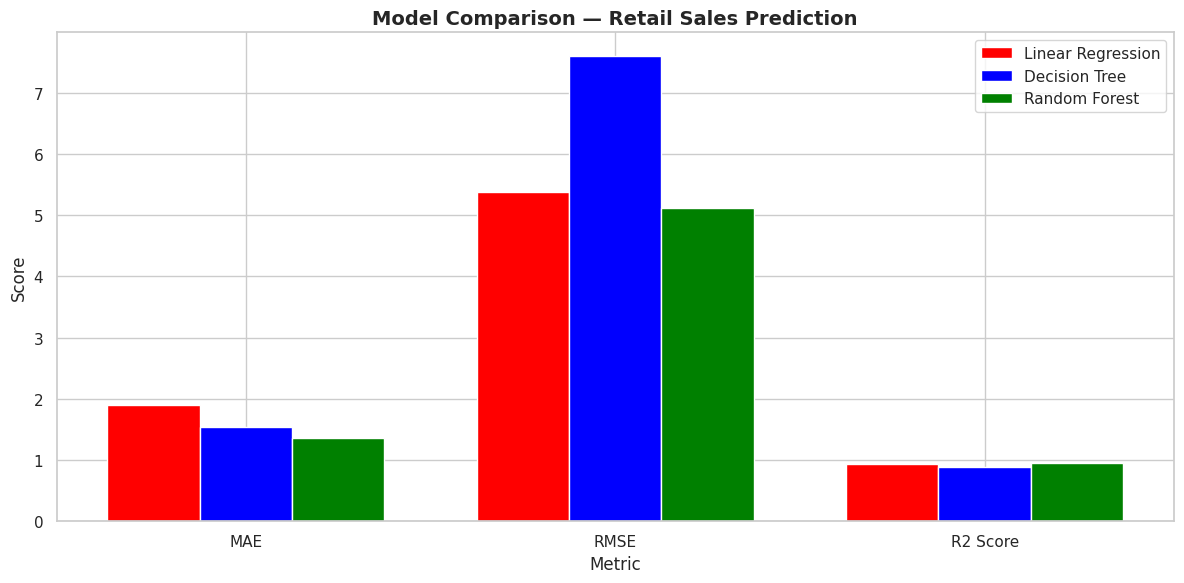

In [14]:
metrics = ['MAE', 'RMSE', 'R2 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, retail_results.set_index('Model').loc['Linear Regression', metrics],
       width, label='Linear Regression', color='Red')
ax.bar(x,         retail_results.set_index('Model').loc['Decision Tree', metrics],
       width, label='Decision Tree',     color='Blue')
ax.bar(x + width, retail_results.set_index('Model').loc['Random Forest', metrics],
       width, label='Random Forest',     color='Green')

ax.set_title('Model Comparison — Retail Sales Prediction',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig('retail_model_comparison.png', dpi=150)
plt.show()

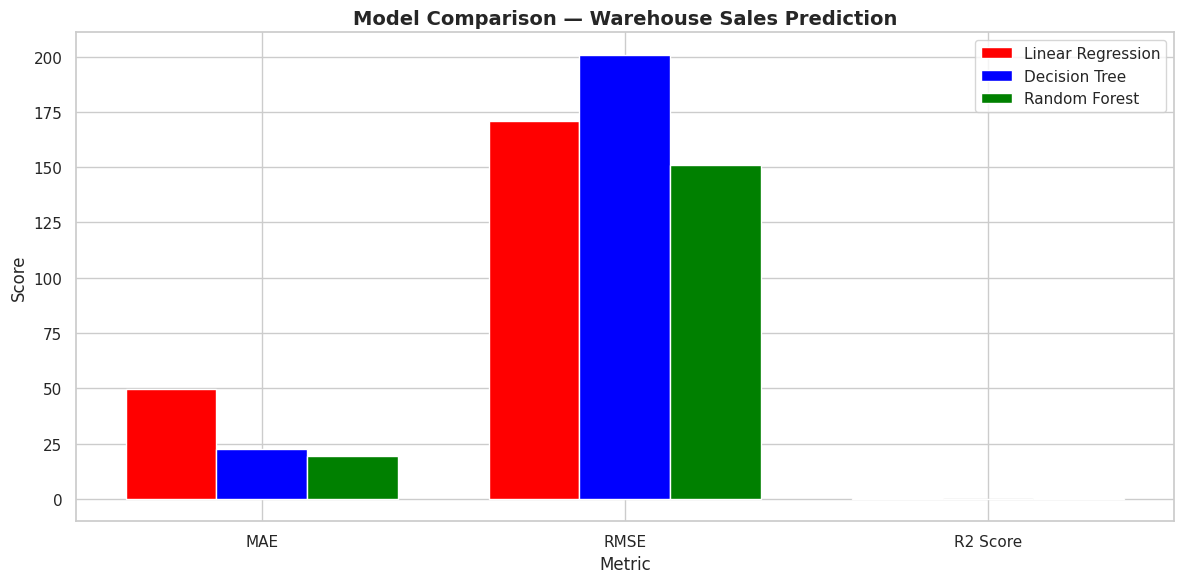

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, warehouse_results.set_index('Model').loc['Linear Regression', metrics],
       width, label='Linear Regression', color='Red')
ax.bar(x,         warehouse_results.set_index('Model').loc['Decision Tree', metrics],
       width, label='Decision Tree',     color='Blue')
ax.bar(x + width, warehouse_results.set_index('Model').loc['Random Forest', metrics],
       width, label='Random Forest',     color='Green')

ax.set_title('Model Comparison — Warehouse Sales Prediction',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.savefig('warehouse_model_comparison.png', dpi=150)
plt.show()

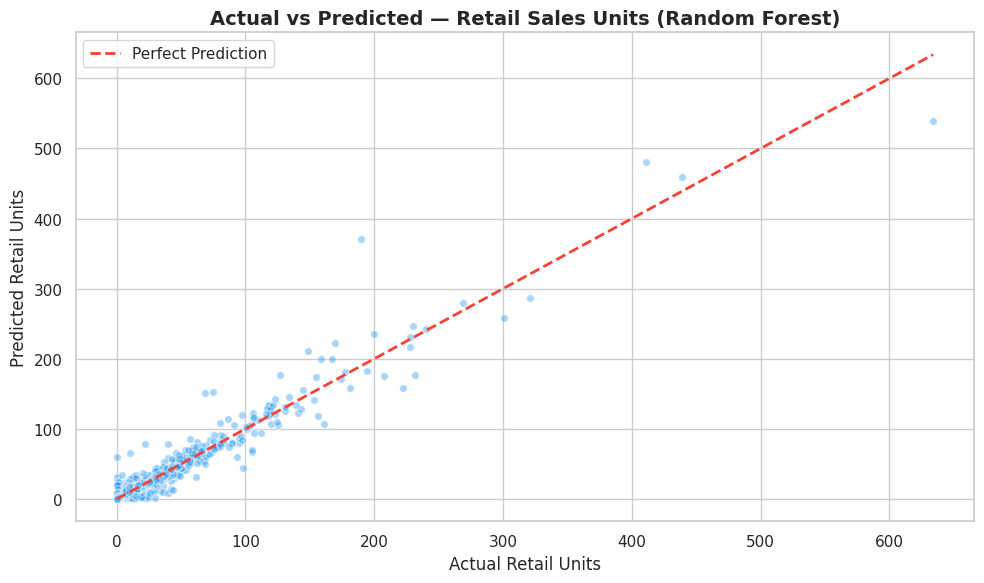

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_r, rf_retail_pred,
           alpha=0.4, color='#2196F3', edgecolors='white', s=30)

# Perfect prediction line
min_val = min(y_test_r.min(), rf_retail_pred.min())
max_val = max(y_test_r.max(), rf_retail_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#F44336', linewidth=2, linestyle='--', label='Perfect Prediction')

ax.set_title('Actual vs Predicted — Retail Sales Units (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Retail Units')
ax.set_ylabel('Predicted Retail Units')
ax.legend()
plt.tight_layout()
plt.savefig('retail_actual_vs_predicted.png', dpi=150)
plt.show()

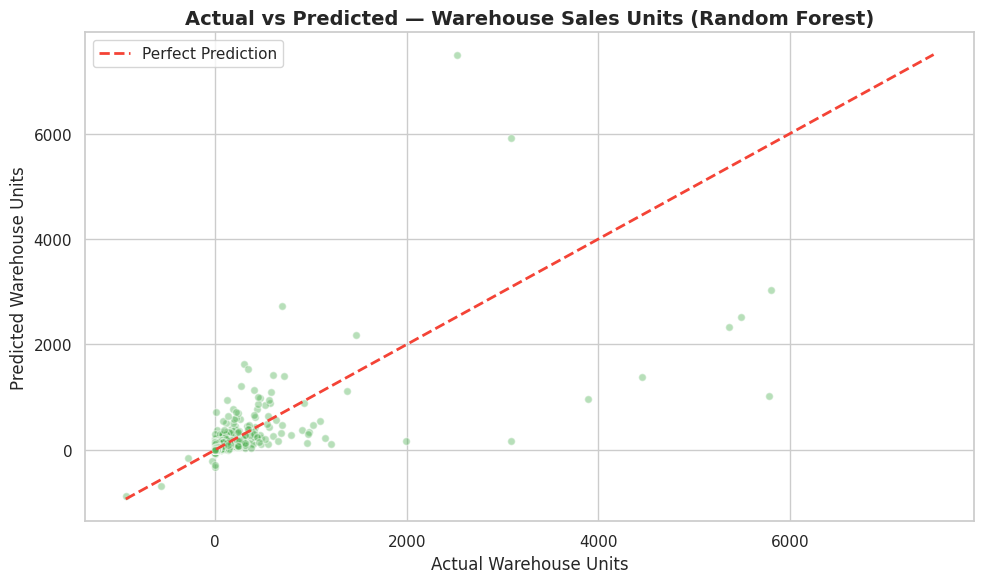

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test_w, rf_warehouse_pred,
           alpha=0.4, color='#4CAF50', edgecolors='white', s=30)

min_val = min(y_test_w.min(), rf_warehouse_pred.min())
max_val = max(y_test_w.max(), rf_warehouse_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#F44336', linewidth=2, linestyle='--', label='Perfect Prediction')

ax.set_title('Actual vs Predicted — Warehouse Sales Units (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Warehouse Units')
ax.set_ylabel('Predicted Warehouse Units')
ax.legend()
plt.tight_layout()
plt.savefig('warehouse_actual_vs_predicted.png', dpi=150)
plt.show()

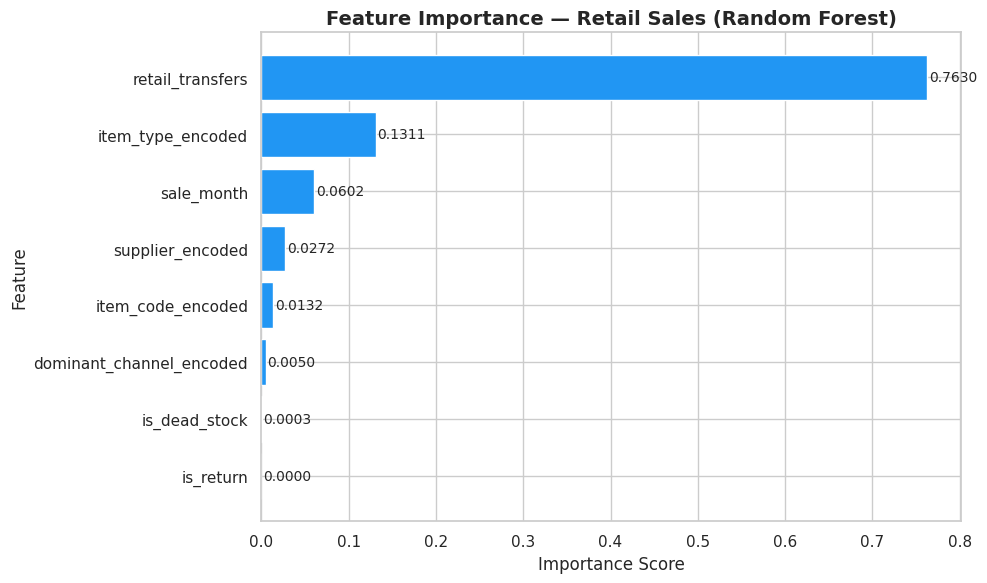

In [18]:
feat_importance_retail = pd.DataFrame({
    'Feature':   FEATURES,
    'Importance': rf_retail.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    feat_importance_retail['Feature'],
    feat_importance_retail['Importance'],
    color='#2196F3',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va='center', fontsize=10
    )

ax.set_title('Feature Importance — Retail Sales (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('retail_feature_importance.png', dpi=150)
plt.show()

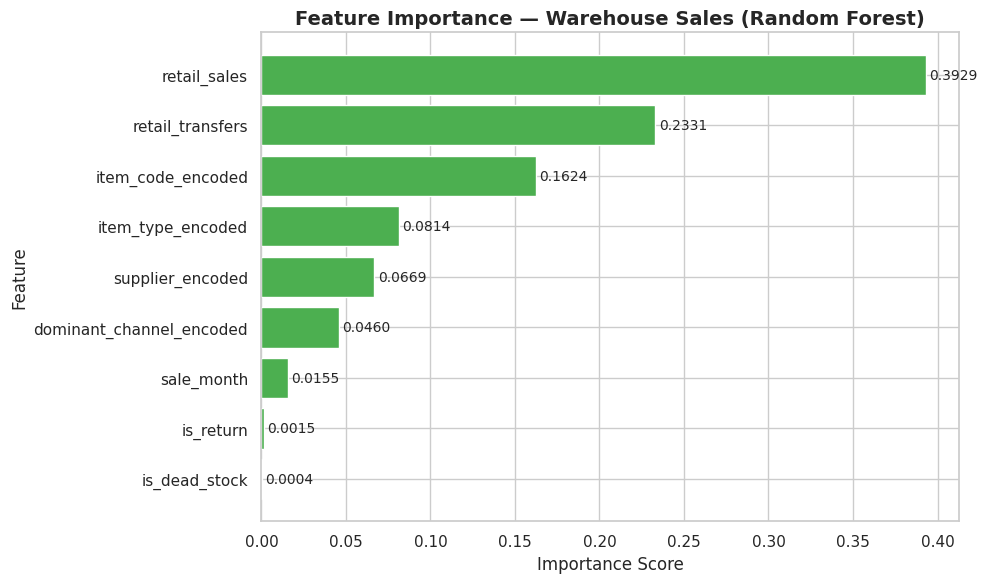

In [19]:
feat_importance_wh = pd.DataFrame({
    'Feature':    FEATURES_WH,
    'Importance': rf_warehouse.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    feat_importance_wh['Feature'],
    feat_importance_wh['Importance'],
    color='#4CAF50',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va='center', fontsize=10
    )

ax.set_title('Feature Importance — Warehouse Sales (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('warehouse_feature_importance.png', dpi=150)